# Digital images

In [2]:
import numpy as np
import skimage.io as io
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from skimage.transform import resize

## Moiré

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0011526607732865962..255.0].


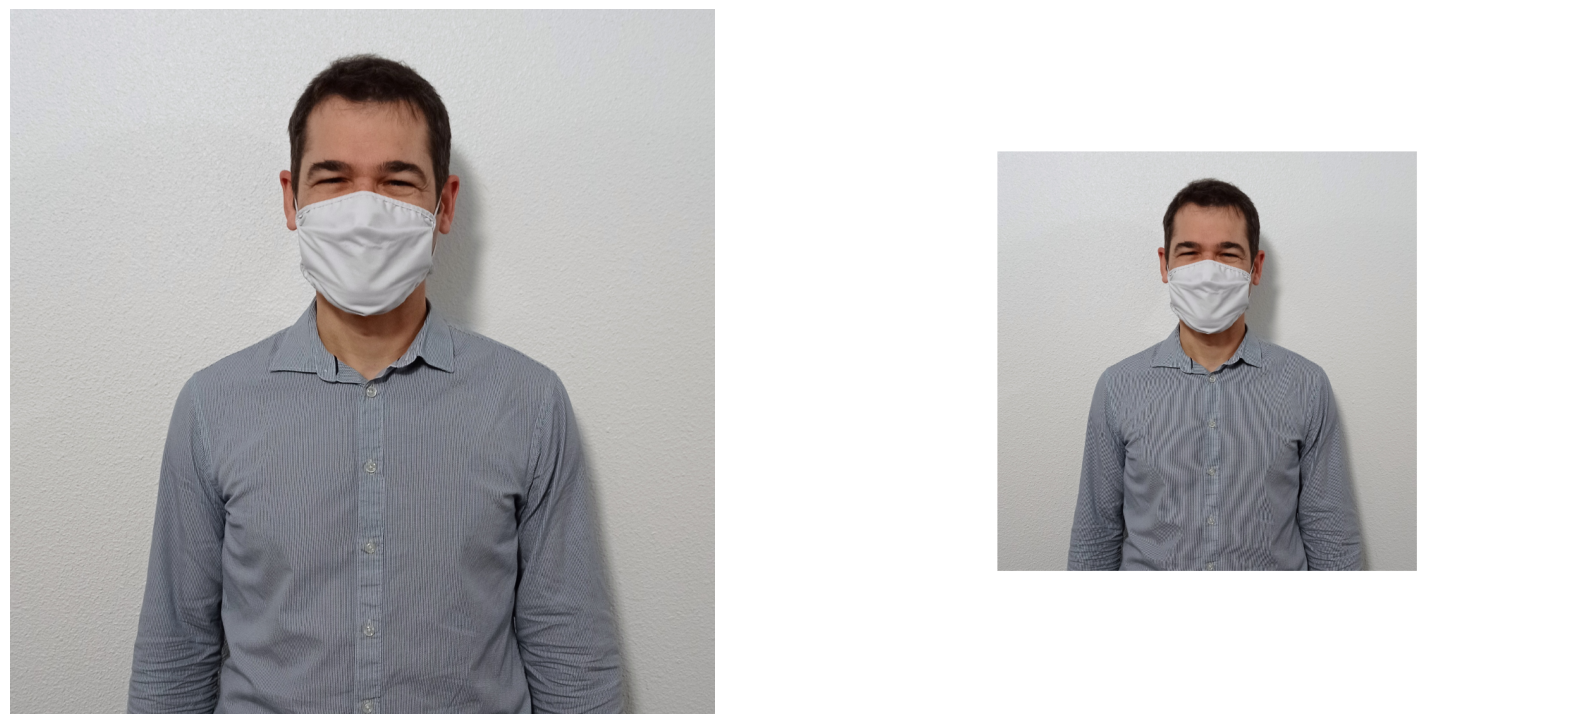

In [7]:
# Load image
img = io.imread("../../src/figs/aliasing-moi.jpg")

# Crop image
r, c = (0, 0)
crop_size = 2000
img = img[ r:(r+crop_size) , c:(c+crop_size) , : ]

#Resize image
N1, N2 = 1000, 595
B = (N1-N2)//2
img1 = resize(img, (N1,N1,3), anti_aliasing=True)
imgx = resize(img1, (N2,N2,3), anti_aliasing=False)
img2 = np.ones((N1,N1,3))*255
img2[B:B+N2,B:B+N2,:] = imgx
# img2 = imgx

fig, axs = plt.subplots(1,2, figsize=(20,10))
axs[0].imshow(img1)
axs[0].axis('off')
axs[1].imshow(img2)
axs[1].axis('off')
plt.savefig("moire.jpg", bbox_inches="tight")

## Quantization

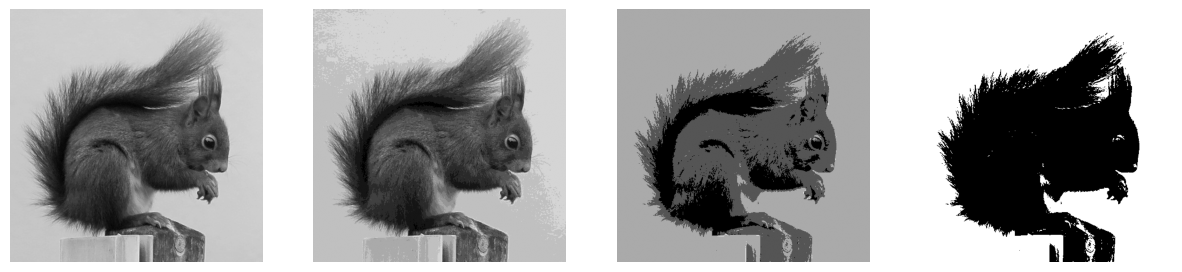

In [9]:
# Load image
img = io.imread("../../src/figs/squirrel.png")

fig, axs = plt.subplots(1, 4, figsize=(15,5))
Q = 2**np.array([0, 4, 6, 7])
for i in range(len(Q)):
    N = Q[i]
    new = (img//N)*N
    axs[i].imshow(new, "gray")
    axs[i].axis("off")
plt.savefig("quantization.png", bbox_inches="tight")
plt.show()

## Colormap

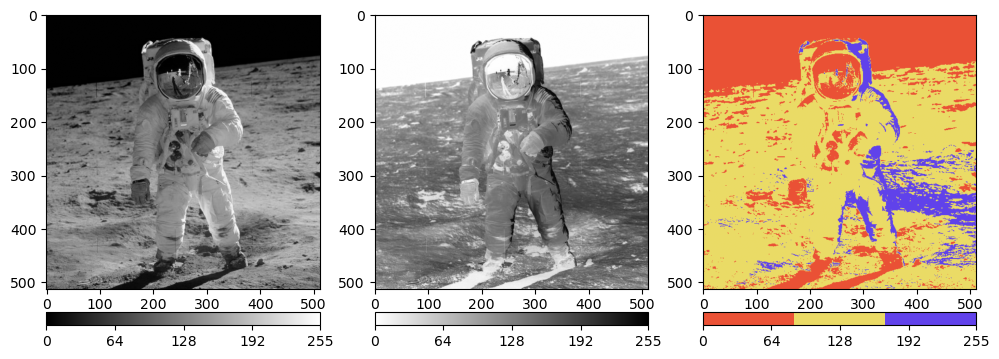

In [7]:
# Image
img = io.imread("../../src/figs/aldrin.png", as_gray=True) * 255

# Colormaps
colormaps = [0]*3

# Colormap 1
colormaps[0] = "gray"

# Colormap 2
C = [np.linspace(1,0,256)]
C = np.tile(C, (3,1)).T
colormaps[1] = ListedColormap(C)

# Colormap 3
C = [[.92, .32, .21], [.92, .86, 0.40], [.38, .26, .92]]
colormaps[2] = ListedColormap(C)

# Affichage
n = len(colormaps)
fig, axs = plt.subplots(1, n, figsize=(n*4, 6))
for [ax, cmap] in zip(axs.flat, colormaps):
    psm = ax.imshow(img, cmap=cmap, vmin=0, vmax=255)
    fig.colorbar(psm, ax=ax, orientation="horizontal", pad = 0.05, shrink=1.0, ticks=[0, 64, 128, 192, 255])
    
plt.savefig("colormaps.svg", transparent=True, bbox_inches="tight")

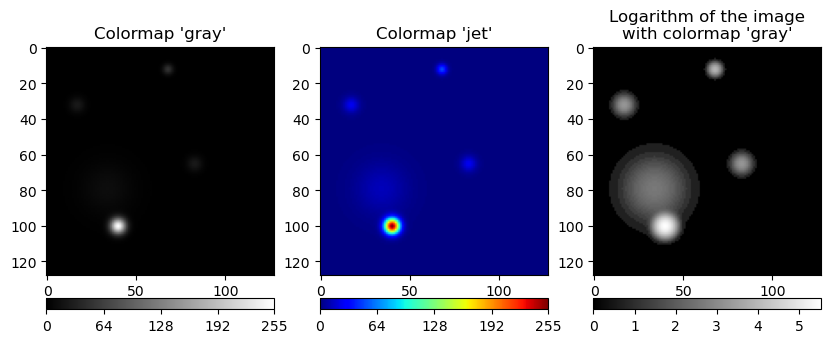

In [8]:
# Load the image
img = io.imread("../../src/figs/spots.png")

# Prepare the figure with three images
fig, axs = plt.subplots(1, 3, figsize=(10, 6))

# Arguments for colorbar
kwargs = { "orientation":"horizontal", "pad": 0.05, "shrink": 1.0 }

# Display the image with colormap gray
im = axs[0].imshow(img, cmap="gray")
axs[0].set_title("Colormap 'gray'")
fig.colorbar(im, ax=axs[0], ticks=[0, 64, 128, 192, 255], **kwargs)

# Display the image with colormap jet
im = axs[1].imshow(img, cmap="jet" )
axs[1].set_title("Colormap 'jet'")
fig.colorbar(im, ax=axs[1], ticks=[0, 64, 128, 192, 255], **kwargs)

# Display the logarithm of the image
img_log = np.log(1. + img)
im = axs[2].imshow(img_log, cmap="gray")
axs[2].set_title("Logarithm of the image\nwith colormap 'gray'")
fig.colorbar(im, ax=axs[2], ticks=np.arange(6), **kwargs)

# Show the figure
plt.savefig("spots.svg", transparent=True, bbox_inches="tight")
plt.show()

## Operations

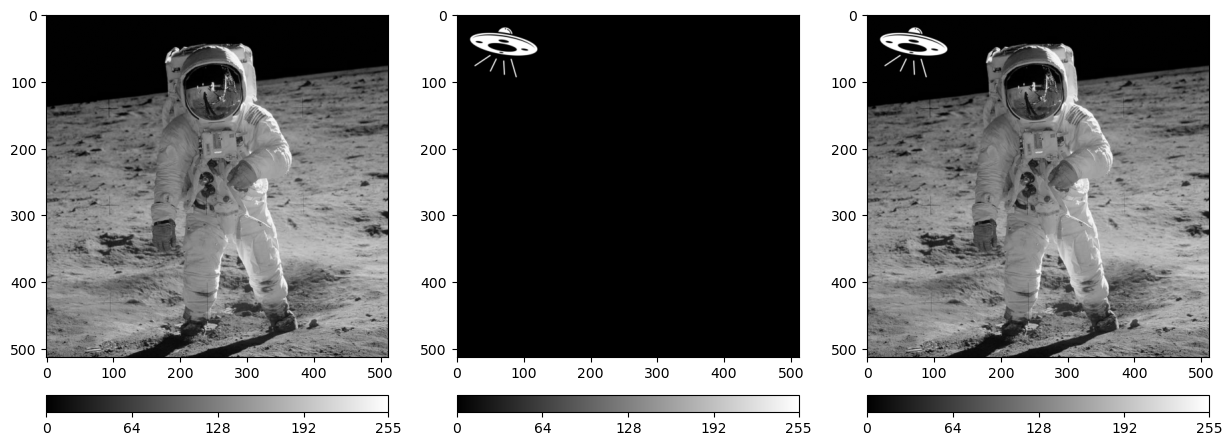

In [15]:
# Image
img1 = io.imread("../../src/figs/aldrin.png", as_gray=True) * 255
img2 = io.imread("../../src/figs/ufo.png")
imgs = [img1, img2, img1+img2]

N = 3
fig, axs = plt.subplots(1, N, figsize=(N*5, 10))
for n in range(N):
    psm = axs[n].imshow(imgs[n], cmap="gray", vmin=0, vmax=255)
    fig.colorbar(psm, ax=axs[n], orientation="horizontal", pad = 0.05, shrink=1.0, ticks=[0, 64, 128, 192, 255])
    
plt.savefig("addition.svg", transparent=True, bbox_inches="tight")

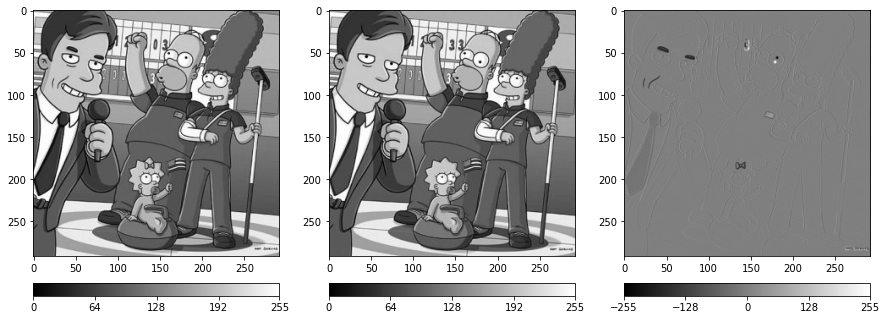

In [4]:
# Image
img1 = io.imread("../figs/simpsons1.png")
img2 = io.imread("../figs/simpsons2.png")
imgs = [img1, img2, img1*1.-img2*1.]
vmins = [0, 0, -255]
ticks = [[0, 64, 128, 192, 255], [0, 64, 128, 192, 255], [-255, -128, 0, 128, 255]]

N = 3
fig, axs = plt.subplots(1, N, figsize=(N*5, 10))
for n in range(N):
    psm = axs[n].imshow(imgs[n], cmap="gray", vmin=vmins[n], vmax=255)
    fig.colorbar(psm, ax=axs[n], orientation="horizontal", pad = 0.05, shrink=1.0, ticks=ticks[n])
    
plt.savefig("subtraction.svg", transparent=True, bbox_inches="tight")

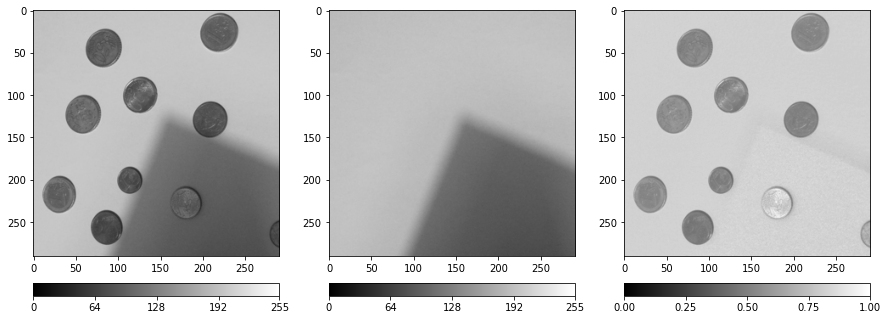

In [5]:
import skimage.util as util
# Image
img1 = io.imread("../figs/coins1.png")
img2 = io.imrebad("../figs/coins2.png")
imgd = 1.*img1/img2
imgd = imgd/imgd.max()
imgs = [img1, img2, imgd]

vmaxs = [255, 255, 1]
ticks = [[0, 64, 128, 192, 255], [0, 64, 128, 192, 255], [0, .25, .5, .75, 1]]

N = 3
fig, axs = plt.subplots(1, N, figsize=(N*5, 10))
for n in range(N):
    psm = axs[n].imshow(imgs[n], cmap="gray", vmin=0, vmax=vmaxs[n])
    fig.colorbar(psm, ax=axs[n], orientation="horizontal", pad = 0.05, shrink=1.0, ticks=ticks[n])
    
plt.savefig("division.svg", transparent=True, bbox_inches="tight")